Accuracy: 0.9704

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



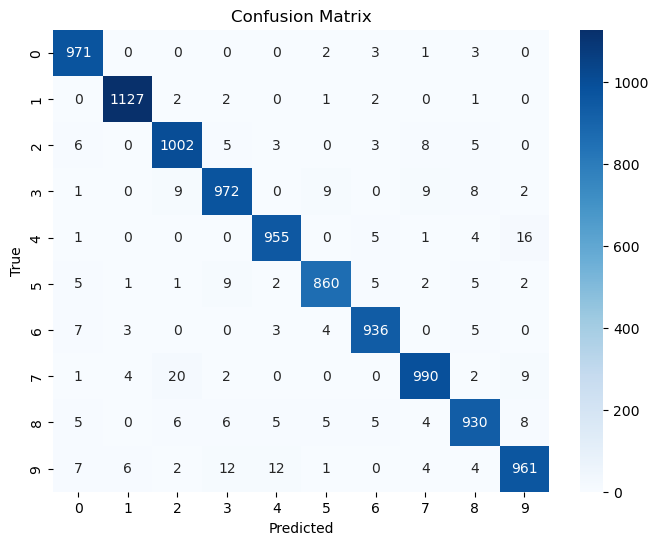

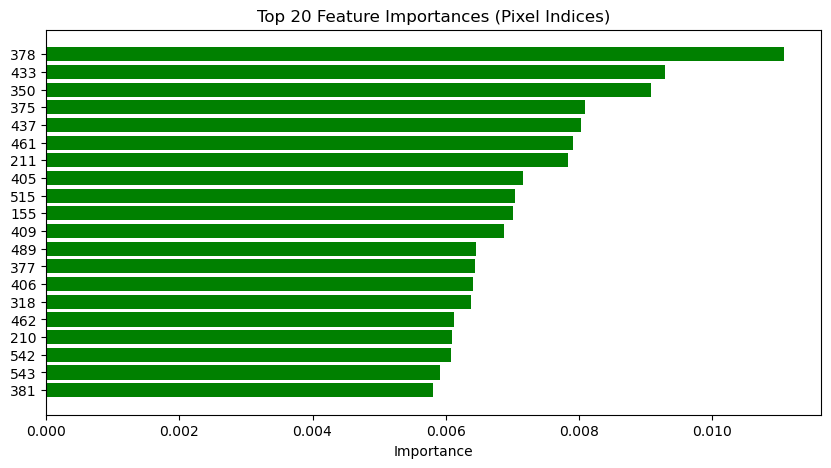

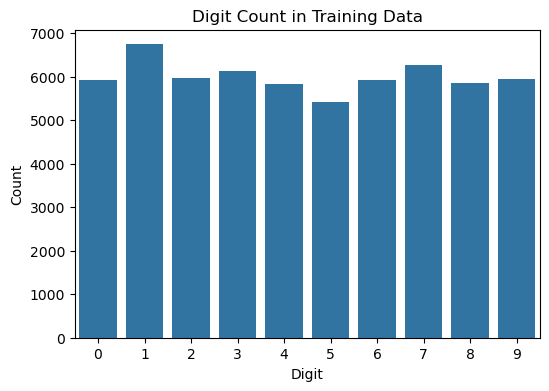

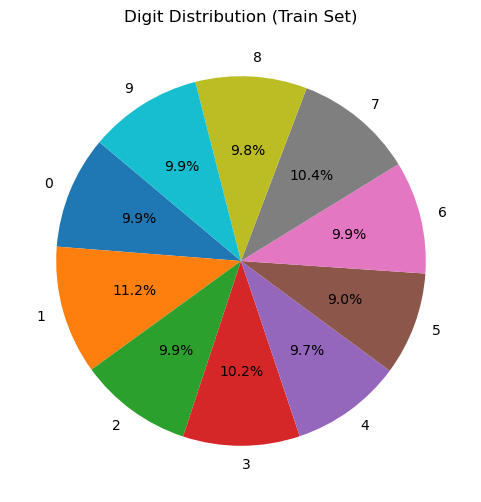

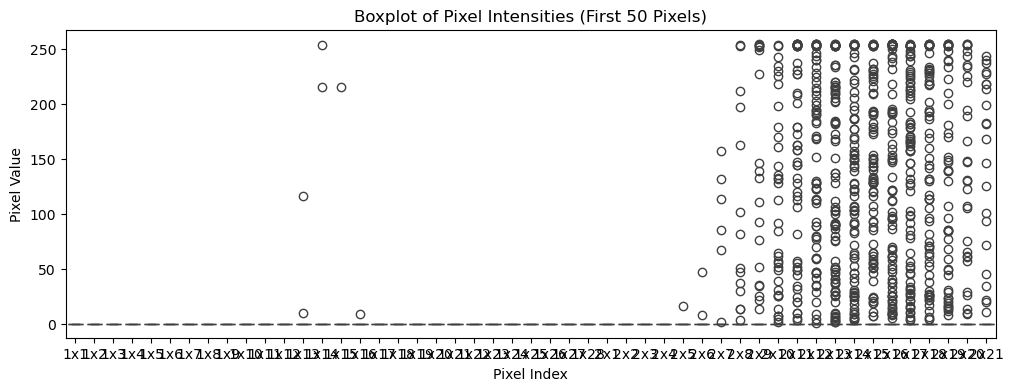

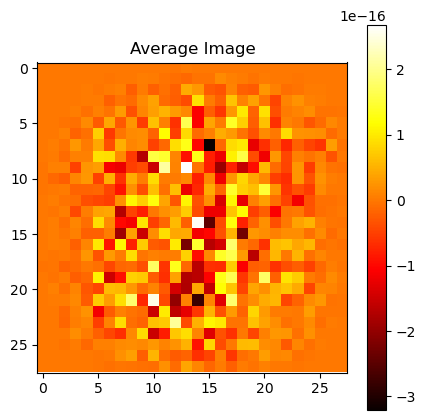

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load MNIST CSV files
train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

# Separate features and labels
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values
X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Normalize pixels to [0,1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Optional standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# === EVALUATION ===
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# === CONFUSION MATRIX ===
conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# === FEATURE IMPORTANCE (Top 20) ===
importances = clf.feature_importances_
indices = np.argsort(importances)[-20:]  # Top 20 pixels

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices], color='green')
plt.yticks(ticks=range(len(indices)), labels=indices)
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (Pixel Indices)")
plt.show()

# === DIGIT COUNT HISTOGRAM ===
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Digit Count in Training Data")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

# === PIE CHART OF LABELS ===
label_counts = pd.Series(y_train).value_counts().sort_index()
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Digit Distribution (Train Set)")
plt.show()

# === BOX PLOT OF PIXEL INTENSITY ===
sample_pixels = train_df.iloc[:, 1:50]  # First 50 pixels
plt.figure(figsize=(12, 4))
sns.boxplot(data=sample_pixels)
plt.title("Boxplot of Pixel Intensities (First 50 Pixels)")
plt.xlabel("Pixel Index")
plt.ylabel("Pixel Value")
plt.show()

# === LINE PLOT OF AVERAGE IMAGE ===
mean_image = np.mean(X_train, axis=0).reshape(28, 28)
plt.figure(figsize=(5, 5))
plt.imshow(mean_image, cmap='hot')
plt.title("Average Image")
plt.colorbar()
plt.show()
